In [1]:
library(ggplot2)
library(tidyverse)
library(reshape2)
library(FSA)
library(agricolae)

── Attaching packages ─────────────────────────────────────── tidyverse 1.3.2 ──
✔ tibble  3.3.0     ✔ dplyr   1.1.4
✔ tidyr   1.3.0     ✔ stringr 1.5.2
✔ readr   2.1.3     ✔ forcats 1.0.0
✔ purrr   1.0.1     
Warning message:
"package 'dplyr' was built under R version 4.2.3"
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()

Attaching package: 'reshape2'


The following object is masked from 'package:tidyr':

    smiths


## FSA v0.10.1. See citation('FSA') if used in publication.
## Run fishR() for related website and fishR('IFAR') for related book.



In [2]:
#my_theme
my_theme = theme(plot.title = element_text(color = "black", size = 20, hjust = 0.5),
                  axis.title.x = element_text(color = "black", size = 20),
                  axis.title.y = element_text(color = "black", size = 20),
                  axis.text.x = element_text(vjust= 0.6,size= 15),
                  axis.text.y = element_text(vjust = 1, size = 15),
                  legend.key.size = unit(40, "pt"),
                  legend.text = element_text(color = "black", size = 20),
                  legend.background = element_rect(fill = "white", color = "white"),
                  legend.key = element_rect(fill = "white"))

## Fig.8D

In [3]:
df = read.csv("asv23.csv")
df = melt(df)
head(df)

No id variables; using all as measure variables



,variable,value
,<fct>,<dbl>
1,Ctrl,1.04136958
2,Ctrl,0.82236767
3,Ctrl,0.96027387
4,D.gal,0.01856722
5,D.gal,0.01812862
6,D.gal,0.02072601


In [4]:
df$variable = factor(df$variable, levels = c("Ctrl", "D.gal", "L.CBD", "H.CBD", "SPD", "Soyb"))

In [5]:
shapiro.test(df$value)


	Shapiro-Wilk normality test

data:  df$value
W = 0.87403, p-value = 0.02074


In [6]:
kruskal.test(value ~ variable, data = df)


	Kruskal-Wallis rank sum test

data:  value by variable
Kruskal-Wallis chi-squared = 11.737, df = 5, p-value = 0.03858


In [7]:
df = df %>% mutate(log_value = log(value + 1))

In [8]:
LSD.test(aov(value~variable, data = df), "variable", group =TRUE)$groups

,value,groups
,<dbl>,<chr>
H.CBD,1.34246753,a
L.CBD,1.07433961,ab
Soyb,1.00115938,b
Ctrl,0.94133704,b
SPD,0.81339592,b
D.gal,0.01914062,c


In [9]:
LSD.test(aov(log_value~variable, data = df), "variable", group =TRUE)$groups

,log_value,groups
,<dbl>,<chr>
H.CBD,0.84106973,a
L.CBD,0.72685537,ab
Soyb,0.69343690,ab
Ctrl,0.66228057,b
SPD,0.59441986,b
D.gal,0.01895912,c


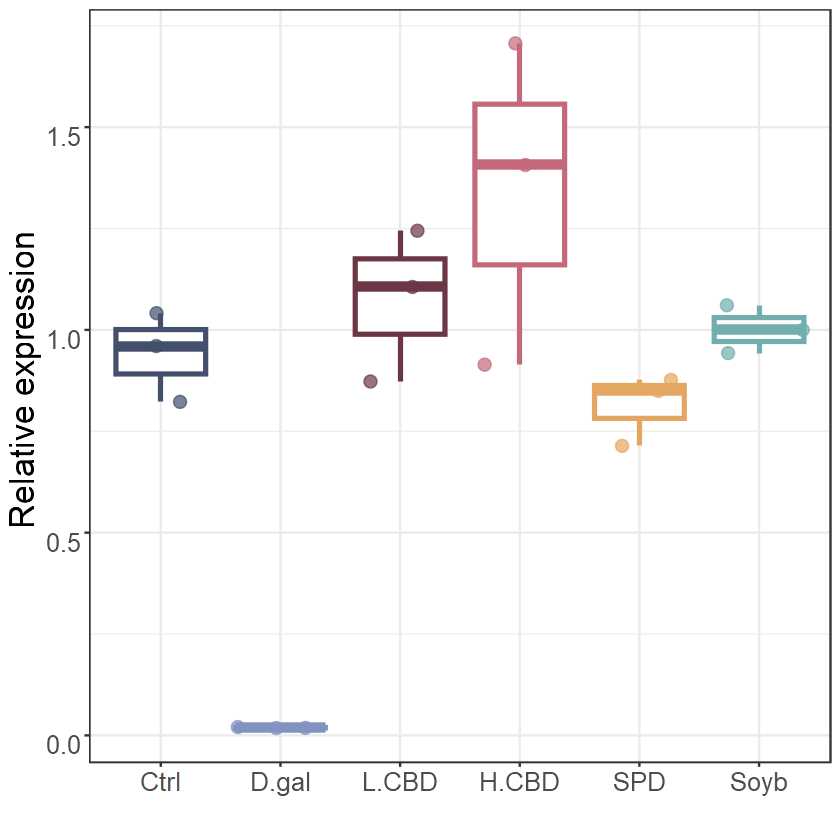

In [10]:
ggplot(df, aes(x = variable, y = value, color = variable)) +
    geom_boxplot(linewidth = 1.1) +
    geom_jitter(size = 3, alpha = 0.7) +
    theme_bw() +
    theme(legend.position = "none") +
    my_theme +
    xlab("") +
    ylab("Relative expression") +
    scale_color_manual(values = c("#434f6b","#8193c0","#6c3745", "#c4697b","#e3a762" ,"#72aeae"))

### Fig.7C

In [11]:
node = read.csv("node.csv") %>% mutate(Group = case_when(Group == "Model" ~ "D_gal", Group == "Soyb" ~ "LA", TRUE ~ Group))
head(node,2)

,X,X1,X2,elements,igraph.degree,igraph.closeness,igraph.betweenness,igraph.cen.degree,group,ID,⋯,kingdom,phylum,class,order,family,genus,species,Group,nodes,label
,<int>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<dbl>,<int>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>
1,1,25.41353,-10.606831,ASV10,20,0.3489168,354.89486,20,Ctrl,ASV10,⋯,k__norank_d__Bacteria,p__Bacteroidota,c__Bacteroidia,o__Bacteroidales,f__Muribaculaceae,g__norank_f__Muribaculaceae,s__unclassified_g__norank_f__Muribaculaceae,Ctrl,307,Ctrl: (nodes: 307; links: )
2,2,17.53087,-2.739244,ASV102,14,0.3272727,19.60808,14,Ctrl,ASV102,⋯,k__norank_d__Bacteria,p__Bacteroidota,c__Bacteroidia,o__Bacteroidales,f__Rikenellaceae,g__Alistipes,s__Alistipes_inops,Ctrl,307,Ctrl: (nodes: 307; links: )


In [12]:
shapiro.test(node$igraph.degree)


	Shapiro-Wilk normality test

data:  node$igraph.degree
W = 0.94213, p-value < 2.2e-16


In [13]:
node$degree_log = log(node$igraph.degree + 1)

In [14]:
LSD.test(aov(degree_log~Group, data = node), "Group", group =TRUE)$groups

,degree_log,groups
,<dbl>,<chr>
H_CBD,3.323889,a
Spd,3.317128,a
Ctrl,3.249045,ab
LA,3.176699,b
L_CBD,3.012819,c
D_gal,2.738525,d


In [15]:
node$Group = factor(node$Group, levels = c("H_CBD", "L_CBD", "D_gal", "Ctrl", "Spd", "LA"))

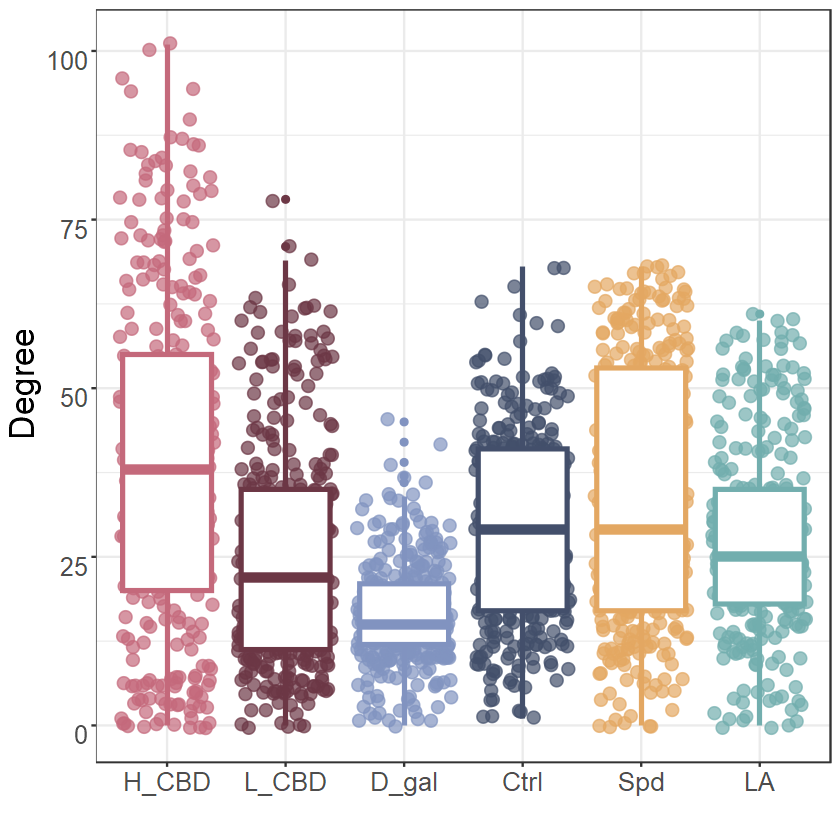

In [16]:
ggplot(node, aes(x = Group, y = igraph.degree, color = Group)) +
    geom_jitter(size = 3, alpha = 0.7) +
    geom_boxplot(linewidth = 1.1) +
    theme_bw() +
    theme(legend.position = "none") +
    my_theme +
    xlab("") +
    ylab("Degree") +
    scale_color_manual(values = c("#c4697b", "#6c3745", "#8193c0", "#434f6b", "#e3a762", "#72aeae"))

### Fig.4J-Aging score

In [17]:
aging = read.csv("dff.csv") %>% mutate(group = case_when(group == "Model" ~ "D_gal", group == "Soyb" ~ "LA", TRUE ~ group))
head(aging,2)

,sample,agingscore,group
,<chr>,<dbl>,<chr>
1,Control1,-0.1812373,Ctrl
2,Control2,-0.1026361,Ctrl


In [18]:
shapiro.test(aging$agingscore)


	Shapiro-Wilk normality test

data:  aging$agingscore
W = 0.94107, p-value = 0.1723


In [19]:
LSD.test(aov(agingscore~group, data = aging), "group", group =TRUE)$groups

,agingscore,groups
,<dbl>,<chr>
D_gal,-0.05725208,a
L_CBD,-0.13446504,b
Ctrl,-0.13736615,b
H_CBD,-0.21991552,c
LA,-0.22999517,c
Spd,-0.23048472,c
